# Sprint 2 — MVP Analítico
## Análise Espacial da Criminalidade no Brasil — Pré-processamento, Engenharia de Atributos e Modelo Baseline de Risco

**Aluno(a):** Cintia Nunes  
**Curso:** Ciência da Computação — UFFS  
**Disciplina:** Planejamento e Gestão de Projetos — Prof. Fabrício Herpich

Este notebook dá continuidade à Sprint 1 (EDA). Ele:

1. carrega os dados processados exportados na Sprint 1 (`sinesp_resumo_2015_2026.csv` e, opcionalmente, `cobertura_2015_2026.csv`);
2. constrói um **painel UF × Ano**, com um indicador escolhido como alvo e os demais indicadores como atributos auxiliares;
3. consulta a população por UF e ano no SIDRA/IBGE e calcula taxas por 100 mil habitantes;
4. faz engenharia de atributos temporais (defasagem, variação percentual);
5. define uma variável de **risco** (Baixo / Médio / Alto), a partir de tercis da taxa do indicador-alvo;
6. separa treino e teste **por ano** (para simular uso prospectivo do modelo, evitando vazamento temporal);
7. treina e compara modelos baseline de classificação (Dummy, Regressão Logística e Random Forest);
8. avalia com acurácia, F1-macro e matriz de confusão;
9. exporta o modelo treinado (`joblib`) e a tabela de métricas.

Seguindo a DSRM, esta sprint corresponde à fase de **Design e Desenvolvimento**: o ciclo de vida de Machine Learning (preparo dos dados → definição do alvo → treino → avaliação → exportação do artefato) é conduzido de forma iterativa e documentado passo a passo.

## 1. Preparação do ambiente

In [29]:
import sys
import subprocess
import importlib.util

pacotes = {
    "pandas": "pandas",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "requests": "requests",
    "scikit-learn": "scikit-learn",
    "joblib": "joblib",
    "ipywidgets": "ipywidgets",
}

faltando = [
    pacote
    for modulo, pacote in pacotes.items()
    if importlib.util.find_spec(modulo.replace("-", "_")) is None
]

if faltando:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltando])

print("Ambiente preparado.")

Ambiente preparado.


In [30]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
import joblib
import ipywidgets as widgets
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

PASTA_PROCESSADOS = Path("dados/processados")
PASTA_RESULTADOS = Path("resultados")
PASTA_MODELOS = Path("modelos")

for pasta in [PASTA_PROCESSADOS, PASTA_RESULTADOS, PASTA_MODELOS]:
    pasta.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

print("Pastas preparadas.")

Pastas preparadas.


## 2. Carregamento dos dados processados na Sprint 1

Este notebook parte do arquivo `sinesp_resumo_2015_2026.csv`, exportado ao final do notebook de EDA
(Sprint 1). Ele já contém os dados resumidos por **ano, mês, UF, indicador e abrangência**, com a
coluna `valor` (que prioriza `total_vitima` e usa `total` como alternativa).

Se disponível, o arquivo `cobertura_2015_2026.csv` também é carregado, para identificar anos com
cobertura parcial (menos de 12 meses), que serão excluídos da modelagem.

> Faça o upload dos arquivos exportados na Sprint 1 quando solicitado.

In [31]:
USAR_GOOGLE_DRIVE = False
PASTA_GOOGLE_DRIVE = "/content/drive/MyDrive/Sinesp/processados"

if USAR_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    caminho_resumo = Path(PASTA_GOOGLE_DRIVE) / "sinesp_resumo_2015_2026.csv"
    caminho_cobertura = Path(PASTA_GOOGLE_DRIVE) / "cobertura_2015_2026.csv"
else:
    from google.colab import files

    print("Selecione 'sinesp_resumo_2015_2026.csv' (obrigatório) e, se tiver, 'cobertura_2015_2026.csv'.")
    arquivos_enviados = files.upload()

    caminho_resumo = None
    caminho_cobertura = None

    for nome in arquivos_enviados.keys():
        if "resumo" in nome.lower():
            caminho_resumo = Path(nome)
        elif "cobertura" in nome.lower():
            caminho_cobertura = Path(nome)

if caminho_resumo is None or not caminho_resumo.exists():
    raise RuntimeError("O arquivo de resumo da Sprint 1 (sinesp_resumo_2015_2026.csv) é obrigatório.")

resumo_sinesp = pd.read_csv(caminho_resumo, encoding="utf-8-sig")

if caminho_cobertura is not None and caminho_cobertura.exists():
    cobertura = pd.read_csv(caminho_cobertura, encoding="utf-8-sig")
    anos_parciais = cobertura.loc[cobertura["mes_final"] < 12, "ano"].tolist()
else:
    cobertura = None
    anos_parciais = []

print("Registros carregados:", len(resumo_sinesp))
print("Anos disponíveis:", sorted(resumo_sinesp["ano"].unique()))
print("Anos com cobertura parcial (serão excluídos da modelagem):", anos_parciais)

resumo_sinesp = resumo_sinesp[~resumo_sinesp["ano"].isin(anos_parciais)].copy()

print("Registros após remover anos parciais:", len(resumo_sinesp))

Selecione 'sinesp_resumo_2015_2026.csv' (obrigatório) e, se tiver, 'cobertura_2015_2026.csv'.


Saving cobertura_2015_2026.csv to cobertura_2015_2026.csv
Saving sinesp_resumo_2015_2026.csv to sinesp_resumo_2015_2026 (1).csv
Registros carregados: 133194
Anos disponíveis: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Anos com cobertura parcial (serão excluídos da modelagem): [2026]
Registros após remover anos parciais: 127312


## 3. Escolha do indicador-alvo

O indicador-alvo é aquele cuja taxa por 100 mil habitantes será usada para definir o **nível de
risco** (variável a ser prevista). Os demais indicadores entram como atributos (features) auxiliares
do modelo, junto com a defasagem (lag) do próprio indicador-alvo.

In [32]:
indicadores_disponiveis = sorted(resumo_sinesp["indicador"].dropna().unique().tolist())

seletor_indicador_alvo = widgets.Dropdown(
    options=indicadores_disponiveis,
    description="Indicador-alvo:",
    style={"description_width": "120px"},
    layout=widgets.Layout(width="750px"),
)

display(seletor_indicador_alvo)

Dropdown(description='Indicador-alvo:', layout=Layout(width='750px'), options=('Arma de Fogo Apreendida', 'Ate…

In [45]:
INDICADOR_ALVO = seletor_indicador_alvo.value

print("Indicador-alvo selecionado:", INDICADOR_ALVO)

Indicador-alvo selecionado: Tentativa de feminicídio


## 4. Construção do painel UF × Ano

O painel agrega o `valor` por UF, ano e indicador (somando as abrangências disponíveis) e depois
"espalha" os indicadores em colunas, de forma que cada linha represente uma combinação
**(UF, Ano)** e cada coluna seja o total de um indicador naquele ano. Essa é a base da engenharia
de atributos: um mesmo ano/UF passa a ter, como atributos, os totais de todos os tipos de
ocorrência registrados.

In [46]:
base_uf_ano = (
    resumo_sinesp
    .groupby(["ano", "uf", "indicador"], as_index=False)["valor"]
    .sum()
)

painel = base_uf_ano.pivot_table(
    index=["ano", "uf"],
    columns="indicador",
    values="valor",
    fill_value=0,
).reset_index()

painel.columns.name = None

print("Dimensão do painel UF x Ano:", painel.shape)
display(painel.head())

Dimensão do painel UF x Ano: (297, 31)


,ano,uf,Arma de Fogo Apreendida,Atendimento pré-hospitalar,Busca e salvamento,Combate a incêndios,Emissão de Alvarás de licença,Estupro,Estupro de vulnerável,Feminicídio,Furto de veículo,Homicídio doloso,Lesão corporal seguida de morte,Mandado de prisão cumprido,Morte de Agente do Estado,Morte no trânsito ou em decorrência dele (exceto homicídio doloso),Morte por intervenção de Agente do Estado,Mortes a esclarecer (sem indício de crime),Mortes no trânsito,Pessoa Desaparecida,Pessoa Localizada,Realização de vistorias,Roubo a instituição financeira,Roubo de carga,Roubo de veículo,Roubo seguido de morte (latrocínio),Suicídio,Suicídio de Agente do Estado,Tentativa de feminicídio,Tentativa de homicídio,Tráfico de drogas
0,2015,AC,14.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,173.0,0.0,0.0,6.0,91.0,12.0,32.0,20.0,0.0,0.0,0.0,0.0,0.0,0.0,12.0,34.0,0.0,0.0,0.0,64.0
1,2015,AL,2033.0,3361.0,1101.0,902.0,5495.0,177.0,472.0,11.0,702.0,1635.0,10.0,1193.0,11.0,644.0,101.0,0.0,118.0,307.0,0.0,6595.0,21.0,95.0,3160.0,55.0,159.0,2.0,0.0,810.0,1400.0
2,2015,AM,535.0,261.0,2342.0,1245.0,1537.0,265.0,598.0,0.0,1760.0,1201.0,9.0,2581.0,5.0,85.0,33.0,42.0,15.0,1047.0,824.0,1872.0,4.0,1.0,2540.0,74.0,136.0,0.0,0.0,396.0,2133.0
3,2015,AP,463.0,4642.0,1535.0,1573.0,3750.0,373.0,0.0,7.0,877.0,235.0,3.0,694.0,0.0,97.0,43.0,9.0,11.0,430.0,0.0,4616.0,1.0,0.0,310.0,21.0,50.0,0.0,0.0,333.0,310.0
4,2015,BA,5647.0,0.0,0.0,0.0,0.0,867.0,1745.0,0.0,5540.0,5709.0,125.0,3510.0,19.0,823.0,0.0,320.0,642.0,2149.0,546.0,0.0,70.0,436.0,14451.0,207.0,363.0,0.0,0.0,3184.0,5714.0


## 5. População por UF e ano (SIDRA/IBGE)

A população é consultada para todos os anos presentes no painel, permitindo calcular taxas por
100 mil habitantes de forma consistente ao longo da série histórica (e não apenas para um único
ano, como na Sprint 1).

In [47]:
SIDRA_TABELA_POP = 6579
SIDRA_VARIAVEL_POP = 9324

CODIGO_UF = {
    11: "RO", 12: "AC", 13: "AM", 14: "RR", 15: "PA", 16: "AP", 17: "TO",
    21: "MA", 22: "PI", 23: "CE", 24: "RN", 25: "PB", 26: "PE", 27: "AL",
    28: "SE", 29: "BA", 31: "MG", 32: "ES", 33: "RJ", 35: "SP", 41: "PR",
    42: "SC", 43: "RS", 50: "MS", 51: "MT", 52: "GO", 53: "DF",
}

def carregar_populacao_uf(ano):
    url = (
        "https://apisidra.ibge.gov.br/values/"
        f"t/{SIDRA_TABELA_POP}/n3/all/"
        f"v/{SIDRA_VARIAVEL_POP}/p/{ano}"
    )
    try:
        resposta = requests.get(url, timeout=60)
        resposta.raise_for_status()
        dados = resposta.json()
    except Exception as erro:
        print(f"Não foi possível consultar a população de {ano}: {erro}")
        return pd.DataFrame(columns=["uf", "ano", "populacao"])

    linhas = []
    for registro in dados[1:]:
        try:
            codigo = int(registro["D1C"])
            populacao = float(registro["V"])
        except (KeyError, ValueError):
            continue
        uf = CODIGO_UF.get(codigo)
        if uf is not None:
            linhas.append({"uf": uf, "ano": int(ano), "populacao": populacao})

    return pd.DataFrame(linhas)

anos_painel = sorted(painel["ano"].unique().tolist())

populacoes = []
for ano in anos_painel:
    print(f"Consultando população de {ano}...")
    populacoes.append(carregar_populacao_uf(ano))

pop_uf_ano = pd.concat(populacoes, ignore_index=True) if populacoes else pd.DataFrame(columns=["uf", "ano", "populacao"])

print("\nAnos com população disponível:", sorted(pop_uf_ano["ano"].unique().tolist()) if not pop_uf_ano.empty else "nenhum")
display(pop_uf_ano.head())

Consultando população de 2015...
Consultando população de 2016...
Consultando população de 2017...
Consultando população de 2018...
Consultando população de 2019...
Consultando população de 2020...
Consultando população de 2021...
Consultando população de 2022...
Consultando população de 2023...
Consultando população de 2024...
Consultando população de 2025...

Anos com população disponível: [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2024, 2025]


,uf,ano,populacao
0,RO,2015,1768204.0
1,AC,2015,803513.0
2,AM,2015,3938336.0
3,RR,2015,505665.0
4,PA,2015,8175113.0


## 6. Cálculo das taxas por 100 mil habitantes

A taxa é calculada para o indicador-alvo (usada como base do risco) e também para o total geral
de ocorrências do ano/UF (usado como atributo de contexto).

In [48]:
painel = painel.merge(pop_uf_ano, on=["uf", "ano"], how="left")

colunas_indicadores = [
    c for c in painel.columns if c not in ["ano", "uf", "populacao"]
]

painel["total_geral"] = painel[colunas_indicadores].sum(axis=1)

if INDICADOR_ALVO not in painel.columns:
    raise RuntimeError(f"O indicador-alvo '{INDICADOR_ALVO}' não foi encontrado no painel.")

painel["taxa_alvo_100k"] = painel[INDICADOR_ALVO] / painel["populacao"] * 100_000
painel["taxa_total_100k"] = painel["total_geral"] / painel["populacao"] * 100_000

print("Registros sem população (taxa não calculável):", painel["populacao"].isna().sum())

painel = painel.dropna(subset=["populacao"]).copy()

display(
    painel[["ano", "uf", INDICADOR_ALVO, "total_geral", "populacao", "taxa_alvo_100k", "taxa_total_100k"]]
    .sort_values(["ano", "uf"])
    .head(10)
)

Registros sem população (taxa não calculável): 54


,ano,uf,Tentativa de feminicídio,total_geral,populacao,taxa_alvo_100k,taxa_total_100k
0,2015,AC,0.0,462.0,803513.0,0.0,57.497514
1,2015,AL,0.0,30570.0,3340932.0,0.0,915.014134
2,2015,AM,0.0,21541.0,3938336.0,0.0,546.956887
3,2015,AP,0.0,20383.0,766679.0,0.0,2658.609405
4,2015,BA,0.0,52067.0,15203334.0,0.0,342.470934
5,2015,CE,0.0,80749.0,8904459.0,0.0,906.837799
6,2015,DF,0.0,32901.0,2914830.0,0.0,1128.745073
7,2015,ES,0.0,151942.0,3929911.0,0.0,3866.296209
8,2015,GO,0.0,399011.0,6610681.0,0.0,6035.853190
9,2015,MA,0.0,25555.0,6904241.0,0.0,370.134820


## 7. Engenharia de atributos temporais

Para cada UF, calcula-se a taxa do indicador-alvo no ano anterior (`lag`) e a variação percentual
em relação a esse ano anterior. Esses atributos ajudam o modelo a capturar tendência, e não apenas
o nível absoluto de um único ano.

In [57]:
painel = painel.sort_values(["uf", "ano"]).reset_index(drop=True)

painel["taxa_alvo_100k_lag1"] = painel.groupby("uf")["taxa_alvo_100k"].shift(1)

variacao = (
    (painel["taxa_alvo_100k"] - painel["taxa_alvo_100k_lag1"])
    / painel["taxa_alvo_100k_lag1"]
) * 100

# Quando a taxa do ano anterior é 0, a divisão gera infinito.
# Nesses casos, tratamos como ausente (NaN), para o imputador cuidar depois.
painel["variacao_pct_alvo"] = variacao.replace([np.inf, -np.inf], np.nan)

display(
    painel[["uf", "ano", "taxa_alvo_100k", "taxa_alvo_100k_lag1", "variacao_pct_alvo"]]
    .sort_values(["uf", "ano"])
    .head(15)
)

,uf,ano,taxa_alvo_100k,taxa_alvo_100k_lag1,variacao_pct_alvo
0,AC,2015,0.000000,NaN,NaN
1,AC,2016,0.000000,0.000000,NaN
2,AC,2017,0.000000,0.000000,NaN
3,AC,2018,0.000000,0.000000,NaN
4,AC,2019,2.948063,0.000000,NaN
5,AC,2020,1.788769,2.948063,-39.323931
6,AC,2021,1.984836,1.788769,10.961008
7,AC,2024,5.904857,1.984836,197.498498
8,AC,2025,5.766804,5.904857,-2.337954
9,AL,2015,0.000000,NaN,NaN


## 8. Definição da variável de risco (alvo de classificação)

A taxa do indicador-alvo é convertida em três classes de risco (**Baixo, Médio, Alto**), a partir dos
tercis calculados sobre toda a série histórica disponível. Essa é a variável que os modelos vão
aprender a prever a partir dos demais atributos (outros indicadores do mesmo ano, população,
taxa geral e o histórico do próprio indicador-alvo).

Tercil 1: 0.0
Tercil 2: 1.48


,count
risco,
Baixo,94
Alto,81
Médio,68


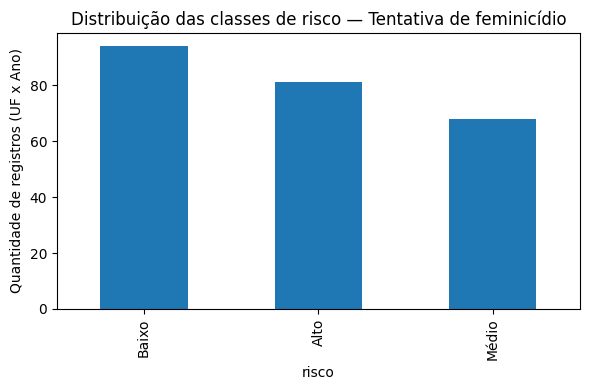

In [58]:
tercil_1 = painel["taxa_alvo_100k"].quantile(1 / 3)
tercil_2 = painel["taxa_alvo_100k"].quantile(2 / 3)

def classificar_risco(taxa):
    if pd.isna(taxa):
        return np.nan
    if taxa <= tercil_1:
        return "Baixo"
    if taxa <= tercil_2:
        return "Médio"
    return "Alto"

painel["risco"] = painel["taxa_alvo_100k"].apply(classificar_risco)

print("Tercil 1:", round(tercil_1, 2))
print("Tercil 2:", round(tercil_2, 2))

display(painel["risco"].value_counts())

painel["risco"].value_counts().plot(kind="bar", figsize=(6, 4), title=f"Distribuição das classes de risco — {INDICADOR_ALVO}")
plt.ylabel("Quantidade de registros (UF x Ano)")
plt.tight_layout()
plt.show()

## 9. Separação treino/teste por ano

Para simular o uso real do modelo (estimar o risco de anos futuros com base em anos anteriores),
a separação entre treino e teste é feita **por ano**, e não aleatoriamente: os anos mais recentes
completos ficam reservados para teste. Registros sem `lag` (primeiro ano de cada UF na série) são
descartados, pois não possuem histórico anterior disponível.

In [59]:
painel_modelo = painel.dropna(subset=["taxa_alvo_100k_lag1", "risco"]).copy()

anos_disponiveis_modelo = sorted(painel_modelo["ano"].unique().tolist())
print("Anos disponíveis para modelagem:", anos_disponiveis_modelo)

PROPORCAO_TESTE_ANOS = 0.25
n_anos_teste = max(1, round(len(anos_disponiveis_modelo) * PROPORCAO_TESTE_ANOS))
anos_teste = anos_disponiveis_modelo[-n_anos_teste:]
anos_treino = [a for a in anos_disponiveis_modelo if a not in anos_teste]

print("Anos de treino:", anos_treino)
print("Anos de teste:", anos_teste)

treino = painel_modelo[painel_modelo["ano"].isin(anos_treino)].copy()
teste = painel_modelo[painel_modelo["ano"].isin(anos_teste)].copy()

colunas_excluidas = ["ano", "uf", "risco", "taxa_alvo_100k", INDICADOR_ALVO]
atributos = [c for c in painel_modelo.columns if c not in colunas_excluidas]

X_treino, y_treino = treino[atributos], treino["risco"]
X_teste, y_teste = teste[atributos], teste["risco"]

print("\nRegistros de treino:", len(X_treino))
print("Registros de teste:", len(X_teste))
print("Atributos utilizados:", len(atributos))

Anos disponíveis para modelagem: [2016, 2017, 2018, 2019, 2020, 2021, 2024, 2025]
Anos de treino: [2016, 2017, 2018, 2019, 2020, 2021]
Anos de teste: [2024, 2025]

Registros de treino: 162
Registros de teste: 54
Atributos utilizados: 33


## 10. Pipeline de pré-processamento

Todos os atributos são numéricos (contagens de ocorrências, população e taxas). O pré-processamento
trata valores ausentes (imputação pela mediana) e padroniza a escala das variáveis, o que é
particularmente importante para a Regressão Logística.

In [60]:
from sklearn.preprocessing import FunctionTransformer

def limpar_infinitos(X):
    X = np.asarray(X, dtype=float)
    return np.where(np.isinf(X), np.nan, X)

pre_processamento = ColumnTransformer(
    transformers=[
        ("numericas", Pipeline(steps=[
            ("remover_infinitos", FunctionTransformer(limpar_infinitos)),
            ("imputador", SimpleImputer(strategy="median")),
            ("padronizador", StandardScaler()),
        ]), atributos),
    ]
)

## 11. Modelos baseline e comparação

São comparados três modelos:

- **Dummy (estratificado)**: referência mínima, prevê respeitando apenas a proporção das classes.
- **Regressão Logística**: modelo linear simples e interpretável.
- **Random Forest**: modelo não linear, capaz de capturar interações entre indicadores.

A comparação usa acurácia e **F1-macro** (mais adequado que acurácia simples quando as classes
podem ficar desbalanceadas entre treino e teste).

In [61]:
modelos = {
    "Dummy (estratificado)": DummyClassifier(strategy="stratified", random_state=RANDOM_STATE),
    "Regressão Logística": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
}

resultados = []
pipelines_treinados = {}

for nome, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ("pre_processamento", pre_processamento),
        ("modelo", modelo),
    ])

    pipeline.fit(X_treino, y_treino)
    y_previsto = pipeline.predict(X_teste)

    acuracia = accuracy_score(y_teste, y_previsto)
    f1_macro = f1_score(y_teste, y_previsto, average="macro")

    resultados.append({
        "modelo": nome,
        "acuracia": round(acuracia, 4),
        "f1_macro": round(f1_macro, 4),
    })

    pipelines_treinados[nome] = pipeline

    print(f"\n=== {nome} ===")
    print(classification_report(y_teste, y_previsto, zero_division=0))

tabela_resultados = pd.DataFrame(resultados).sort_values("f1_macro", ascending=False)
display(tabela_resultados)


=== Dummy (estratificado) ===
              precision    recall  f1-score   support

        Alto       0.78      0.16      0.27        43
       Baixo       0.04      1.00      0.07         1
       Médio       0.17      0.30      0.21        10

    accuracy                           0.20        54
   macro avg       0.33      0.49      0.18        54
weighted avg       0.65      0.20      0.26        54


=== Regressão Logística ===
              precision    recall  f1-score   support

        Alto       0.93      0.65      0.77        43
       Baixo       0.25      1.00      0.40         1
       Médio       0.35      0.70      0.47        10

    accuracy                           0.67        54
   macro avg       0.51      0.78      0.54        54
weighted avg       0.81      0.67      0.70        54


=== Random Forest ===
              precision    recall  f1-score   support

        Alto       1.00      0.65      0.79        43
       Baixo       0.25      1.00      0.40   

,modelo,acuracia,f1_macro
2,Random Forest,0.7037,0.5837
1,Regressão Logística,0.6667,0.5446
0,Dummy (estratificado),0.2037,0.1850


## 12. Matriz de confusão do melhor modelo

Melhor modelo (maior F1-macro): Random Forest


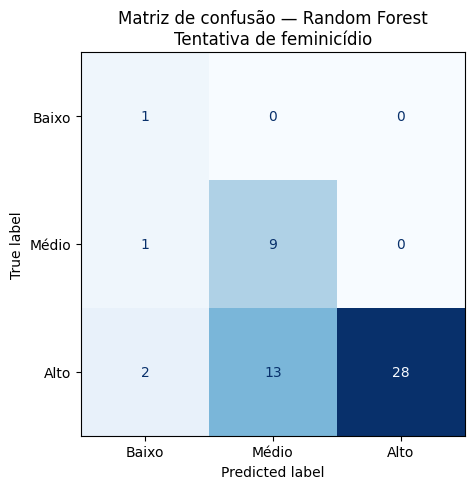

In [62]:
melhor_modelo_nome = tabela_resultados.iloc[0]["modelo"]
melhor_pipeline = pipelines_treinados[melhor_modelo_nome]

print("Melhor modelo (maior F1-macro):", melhor_modelo_nome)

y_previsto_melhor = melhor_pipeline.predict(X_teste)

matriz = confusion_matrix(y_teste, y_previsto_melhor, labels=["Baixo", "Médio", "Alto"])

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(matriz, display_labels=["Baixo", "Médio", "Alto"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusão — {melhor_modelo_nome}\n{INDICADOR_ALVO}")
plt.tight_layout()
plt.show()

## 13. Importância dos atributos (Random Forest)

Quando o Random Forest está entre os modelos treinados, é possível observar quais atributos mais
contribuem para a previsão do risco — por exemplo, se outros tipos de ocorrência, a população ou o
histórico do próprio indicador-alvo (`lag`) pesam mais na classificação.

,atributo,importancia
31,taxa_alvo_100k_lag1,0.157867
6,Estupro de vulnerável,0.083461
18,Pessoa Localizada,0.049790
9,Homicídio doloso,0.047845
32,variacao_pct_alvo,0.042184
14,Morte por intervenção de Agente do Estado,0.039028
12,Morte de Agente do Estado,0.033319
11,Mandado de prisão cumprido,0.030927
5,Estupro,0.030711
30,taxa_total_100k,0.030265


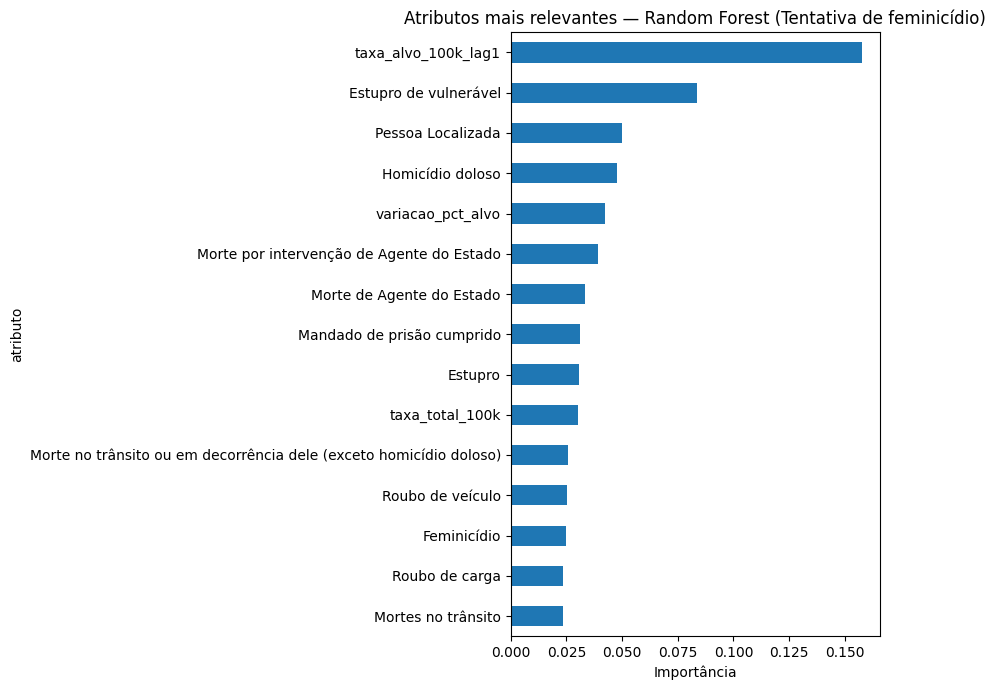

In [63]:
if "Random Forest" in pipelines_treinados:
    rf_pipeline = pipelines_treinados["Random Forest"]
    rf_modelo = rf_pipeline.named_steps["modelo"]

    importancias = pd.DataFrame({
        "atributo": atributos,
        "importancia": rf_modelo.feature_importances_,
    }).sort_values("importancia", ascending=False).head(15)

    display(importancias)

    importancias.sort_values("importancia").plot(
        x="atributo", y="importancia", kind="barh", figsize=(9, 7), legend=False,
        title=f"Atributos mais relevantes — Random Forest ({INDICADOR_ALVO})",
    )
    plt.xlabel("Importância")
    plt.tight_layout()
    plt.show()
else:
    print("Random Forest não está entre os modelos treinados nesta execução.")

## 14. Exportação do modelo e das métricas

O melhor pipeline (pré-processamento + modelo) é exportado com `joblib`, junto com metadados sobre
o experimento (indicador-alvo, atributos utilizados, anos de treino/teste) e a tabela de métricas
comparativas. Esses arquivos devem ser versionados no GitHub, conforme a entrega da Sprint 2.

In [64]:
nome_arquivo_indicador = (
    INDICADOR_ALVO.lower()
    .replace(" ", "_")
    .replace("/", "_")
)

arquivo_modelo = PASTA_MODELOS / f"modelo_risco_{nome_arquivo_indicador}.joblib"
arquivo_metricas = PASTA_RESULTADOS / f"metricas_modelos_{nome_arquivo_indicador}.csv"

metadados = {
    "pipeline": melhor_pipeline,
    "modelo": melhor_modelo_nome,
    "indicador_alvo": INDICADOR_ALVO,
    "atributos": atributos,
    "anos_treino": anos_treino,
    "anos_teste": anos_teste,
    "tercil_1": tercil_1,
    "tercil_2": tercil_2,
    "classes": ["Baixo", "Médio", "Alto"],
}

joblib.dump(metadados, arquivo_modelo)
tabela_resultados.to_csv(arquivo_metricas, index=False, encoding="utf-8-sig")

print("Modelo exportado em:", arquivo_modelo)
print("Métricas exportadas em:", arquivo_metricas)

Modelo exportado em: modelos/modelo_risco_tentativa_de_feminicídio.joblib
Métricas exportadas em: resultados/metricas_modelos_tentativa_de_feminicídio.csv


## 15. Conclusões da Sprint 2

Após executar o notebook, utilize os resultados para registrar no artigo científico:

1. qual indicador foi utilizado como alvo e por quê;
2. quais atributos compõem o painel (outros indicadores, população, taxa geral, lag e variação percentual);
3. como foi feita a separação temporal entre treino e teste, e por que essa escolha evita vazamento de dados;
4. como os modelos baseline (Dummy, Regressão Logística, Random Forest) se compararam em acurácia e F1-macro;
5. quais atributos mais influenciaram o modelo de melhor desempenho;
6. quais limitações foram identificadas (poucos anos disponíveis, classes de risco definidas por tercis, dependência da qualidade do Sinesp VDE).

## 16. Limitações

- O número de anos disponíveis é pequeno para um problema de série temporal, o que limita a robustez da divisão treino/teste.
- As classes de risco (tercis) são uma simplificação: não correspondem a um critério oficial de classificação de risco em segurança pública.
- A ausência de população para algum ano/UF remove essas observações da modelagem.
- O modelo é um **baseline**: etapas futuras podem incluir validação cruzada temporal (walk-forward), ajuste de hiperparâmetros e testes de autocorrelação espacial (Moran/LISA) como atributos adicionais.
- Este notebook não estabelece relação causal para a criminalidade; trata-se de um modelo preditivo/exploratório.